# Step 2b — Mulch confound investigation

Spec: `CLAUDE.md` §6 step 2b (added 2026-09-16).

Step 2 found the median unit **50.3% water-like in VH** before any flooding. If plastic mulch
reflects radar away from the sensor the way standing water does, an absolute-threshold mask cannot
tell them apart, which would explain both the weak agreement with the optical reference and the 11
units above the flooded-fraction threshold against a county figure of 1,919 flooded strawberry acres.

1. **Distributions**, not just medians, of the baseline water-like fraction for units, and for
   non-strawberry comparison fields in the same region (DWR lettuce T30 and cole crops T4), to see
   whether the effect is specific to mulched strawberry beds.
2. **Does the change signal survive?** For units inside the 15 March optical extent versus units
   outside it, compare the **pre-to-post backscatter change**, not the absolute post value,
   restricted to units with a clear optical view on 15 March. If mulch raises the baseline but
   flooding still lowers backscatter further, the mask definition is wrong rather than the method.
3. **Denominator:** how many units fall inside the 15 March optical extent.

If the change signal does not separate the groups, that is a negative result against the §4 kill
criterion on resolving strawberry beds, and it is reported as such. **No threshold tuning.**

**CHECKPOINT:** distributions, change-signal comparison, verdict. Stop before Step 3.

In [1]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common as C
import dwr
import optical
from maps import HALO

ee.Initialize(project=C.EE_PROJECT)

PRE_WINDOW = ("2023-02-01", "2023-03-09")
OPT_DATE = "2023-03-15"          # first post-event optical look at the breach area
AOI_LL = (-121.90, 36.60, -121.55, 36.98)
ABS_VV_DB, ABS_VH_DB = -15.0, -22.0
COMPARISON = {"T30": "lettuce or leafy greens", "T4": "cole crops"}
N_COMPARE = 400                  # fields sampled per comparison crop, seed 0
CLEAR_MIN = 0.5                  # unit needs this share of clear optical view on 15 March
FLOODED_MIN, DRY_MAX = 0.3, 0.05  # share of unit inside the 15 March optical extent

counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
units_fc = ee.FeatureCollection(C.UNITS_ASSET).filter(ee.Filter.eq("is_unit", 1))
units_tbl = pd.read_csv(C.DERIVED / "01_units_dwr.csv")
uu = units_tbl[units_tbl.is_unit.astype(bool)].copy()
uu["unit_id"] = uu.unit_id.astype(str)
N_UNITS = len(uu)

track_tbl = pd.read_csv(C.DERIVED / "02_s1_track_coverage.csv")
row = track_tbl[track_tbl.covers_units & (track_tbl.pre_scenes >= 2)].sort_values("days_after_peak").iloc[0]
PASS, REL_ORBIT, POST_DATE = row["pass"], int(row.rel_orbit), row.post_date
print(f"n units = {N_UNITS} | Sentinel-1 {PASS} relative orbit {REL_ORBIT}, pre "
      f"{PRE_WINDOW[0]} to 2023-03-08, post {POST_DATE} | optical extent {OPT_DATE}")
print(f"datasets: {C.S1}, {C.S2}, {C.UNITS_ASSET}, DWR WY2023 crop map")

n units = 1320 | Sentinel-1 ASCENDING relative orbit 35, pre 2023-02-01 to 2023-03-08, post 2023-03-19 | optical extent 2023-03-15
datasets: COPERNICUS/S1_GRD, COPERNICUS/S2_SR_HARMONIZED, projects/cropczyk/assets/strawberry_fields_dwr_wy2023, DWR WY2023 crop map


## Comparison fields: non-strawberry DWR fields in the same region

In [2]:
fields = dwr.load_fields(2023, ["Monterey", "Santa Cruz"])
cent = fields.to_crs("EPSG:4326").centroid
fields = fields.assign(lon=cent.x, lat=cent.y)
in_aoi = fields.lon.between(AOI_LL[0], AOI_LL[2]) & fields.lat.between(AOI_LL[1], AOI_LL[3])
size_ok = fields.ACRES.between(2, 100)      # comparable in size to the strawberry units

samples = []
for crop, label in COMPARISON.items():
    pool = fields[in_aoi & size_ok & (fields.MAIN_CROP == crop)]
    take = pool.sample(min(N_COMPARE, len(pool)), random_state=0)
    samples.append(take.assign(crop_class=crop))
    print(f"{crop} ({label}): {len(pool)} fields in the valley box, sampled {len(take)}, "
          f"median {take.ACRES.median():.1f} acres")
comp = gpd.GeoDataFrame(pd.concat(samples), crs=fields.crs)
comp["field_id"] = comp.UniqueID.astype(str)
print(f"units (T20 strawberries): {N_UNITS}, median {uu.ACRES.median():.1f} acres")

comp_ll = comp.to_crs("EPSG:4326")
comp_fc = ee.FeatureCollection([
    ee.Feature(ee.Geometry(g.simplify(0.00002).__geo_interface__, None, False),
               {"field_id": fid, "crop_class": cc})
    for g, fid, cc in zip(comp_ll.geometry, comp_ll.field_id, comp_ll.crop_class)])
print(f"comparison collection: {comp_fc.size().getInfo()} fields")
print(f"n units = {N_UNITS} | date window: DWR WY2023 | dataset: DWR WY2023 crop map "
      f"(data/raw/dwr_crop_mapping)")

C:\Users\austi\CROPCZYK\strawberry-index-insurance\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


C:\Users\austi\AppData\Local\Temp\ipykernel_20392\4287179965.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = fields.to_crs("EPSG:4326").centroid


T30 (lettuce or leafy greens): 1617 fields in the valley box, sampled 400, median 13.3 acres
T4 (cole crops): 972 fields in the valley box, sampled 400, median 13.3 acres
units (T20 strawberries): 1320, median 6.2 acres


comparison collection: 800 fields
n units = 1320 | date window: DWR WY2023 | dataset: DWR WY2023 crop map (data/raw/dwr_crop_mapping)


## Backscatter, baseline water-likeness, and the optical extent, per field

In [3]:
s1 = (ee.ImageCollection(C.S1).filterBounds(region)
      .filter(ee.Filter.eq("instrumentMode", "IW"))
      .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
      .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
      .filter(ee.Filter.eq("orbitProperties_pass", PASS))
      .filter(ee.Filter.eq("relativeOrbitNumber_start", REL_ORBIT)))
kernel = ee.Kernel.square(radius=1, units="pixels")
pre_img = s1.filterDate(*PRE_WINDOW).select(["VV", "VH"]).median().focal_mean(kernel=kernel)
post_img = (s1.filterDate(POST_DATE, ee.Date(POST_DATE).advance(1, "day"))
            .select(["VV", "VH"]).mosaic().focal_mean(kernel=kernel))

pre_idx = optical.baseline(region)
opt15 = optical.water_on(region, OPT_DATE, pre_idx, 0.0).rename("opt15")
clear15 = (ee.ImageCollection(C.S2).filterBounds(region)
           .filterDate(OPT_DATE, ee.Date(OPT_DATE).advance(1, "day"))
           .linkCollection(ee.ImageCollection(C.S2_CLOUD), ["cs_cdf"])
           .map(lambda im: im.select("cs_cdf").gt(C.CLEAR_CS_CDF))
           .mosaic().unmask(0).rename("clear15"))

stack = (pre_img.select("VV").lt(ABS_VV_DB).rename("base_vv")
         .addBands(pre_img.select("VH").lt(ABS_VH_DB).rename("base_vh"))
         .addBands(pre_img.select("VV").rename("pre_vv"))
         .addBands(post_img.select("VV").rename("post_vv"))
         .addBands(pre_img.select("VH").rename("pre_vh"))
         .addBands(post_img.select("VH").rename("post_vh"))
         .addBands(opt15)
         .addBands(clear15))
BANDS = ["base_vv", "base_vh", "pre_vv", "post_vv", "pre_vh", "post_vh", "opt15", "clear15"]


def sample_fields(fc, id_prop, ids, chunk=200):
    out = []
    for i in range(0, len(ids), chunk):
        part = fc.filter(ee.Filter.inList(id_prop, ids[i:i + chunk]))
        red = stack.reduceRegions(part, ee.Reducer.mean(), scale=10, tileScale=16)
        out += [f["properties"] for f in
                red.select([id_prop] + BANDS + (["crop_class"] if id_prop == "field_id" else []),
                           retainGeometry=False).getInfo()["features"]]
    return pd.DataFrame(out)


CACHE = C.DERIVED / "02b_field_backscatter.csv"
if CACHE.exists():
    vals = pd.read_csv(CACHE)
    vals["field_id"] = vals.field_id.astype(str)
    print(f"Loaded cached {CACHE.name} (delete it to re-measure)")
else:
    unit_vals = sample_fields(units_fc, "unit_id", uu.unit_id.tolist())
    unit_vals["crop_class"] = "T20"
    unit_vals = unit_vals.rename(columns={"unit_id": "field_id"})
    comp_vals = sample_fields(comp_fc, "field_id", comp.field_id.tolist())
    vals = pd.concat([unit_vals, comp_vals], ignore_index=True)
    for b in BANDS:
        vals[b] = pd.to_numeric(vals[b], errors="coerce")
    vals["d_vv"] = vals.post_vv - vals.pre_vv
    vals["d_vh"] = vals.post_vh - vals.pre_vh
    vals.to_csv(CACHE, index=False)
print(f"fields measured: {len(vals)} ({(vals.crop_class == 'T20').sum()} units, "
      f"{(vals.crop_class != 'T20').sum()} comparison), missing values: {int(vals.pre_vv.isna().sum())}")
print("Wrote 02b_field_backscatter.csv")
print(f"n units = {N_UNITS} | date window: pre {PRE_WINDOW[0]} to 2023-03-08; S1 post {POST_DATE}; "
      f"optical {OPT_DATE} | datasets: {C.S1}, {C.S2}, {C.GSW}")

Loaded cached 02b_field_backscatter.csv (delete it to re-measure)
fields measured: 2120 (1320 units, 800 comparison), missing values: 0
Wrote 02b_field_backscatter.csv
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08; S1 post 2023-03-19; optical 2023-03-15 | datasets: COPERNICUS/S1_GRD, COPERNICUS/S2_SR_HARMONIZED, JRC/GSW1_4/GlobalSurfaceWater


## 1. Distribution of baseline water-like fraction, by crop

In [4]:
LABEL = {"T20": "T20 strawberries (units)", "T30": "T30 lettuce/leafy greens", "T4": "T4 cole crops"}
qs = [0.1, 0.25, 0.5, 0.75, 0.9]
for band, thr in [("base_vv", ABS_VV_DB), ("base_vh", ABS_VH_DB)]:
    rows = []
    for cls, g in vals.groupby("crop_class"):
        d = g[band].dropna()
        r = {"crop": LABEL[cls], "fields": len(d), "mean": d.mean()}
        r.update({f"p{int(q * 100)}": d.quantile(q) for q in qs})
        r["share of fields > 50% water-like"] = (d > 0.5).mean()
        rows.append(r)
    pol = band.split("_")[1].upper()
    print(f"Baseline water-like fraction per field, {pol} < {thr:g} dB, "
          f"{PRE_WINDOW[0]} to 2023-03-08:")
    print(pd.DataFrame(rows).set_index("crop").round(3).to_string())
    print()
print("A field at 1.0 is entirely below the open-water threshold before any flooding.")
print(f"n units = {N_UNITS} | date window: {PRE_WINDOW[0]} to 2023-03-08 | datasets: {C.S1}, "
      f"DWR WY2023 crop map")

Baseline water-like fraction per field, VV < -15 dB, 2023-02-01 to 2023-03-08:
                          fields   mean  p10  p25    p50    p75    p90  share of fields > 50% water-like
crop                                                                                                    
T20 strawberries (units)    1320  0.178  0.0  0.0  0.035  0.267  0.639                             0.143
T30 lettuce/leafy greens     400  0.033  0.0  0.0  0.000  0.003  0.057                             0.022
T4 cole crops                400  0.051  0.0  0.0  0.000  0.015  0.140                             0.030

Baseline water-like fraction per field, VH < -22 dB, 2023-02-01 to 2023-03-08:
                          fields   mean    p10    p25    p50    p75    p90  share of fields > 50% water-like
crop                                                                                                        
T20 strawberries (units)    1320  0.493  0.007  0.189  0.503  0.792  0.951                        

## 2. Denominator: units inside the 15 March optical extent

In [5]:
u = vals[vals.crop_class == "T20"].copy()
clear = u[u.clear15 >= CLEAR_MIN]
rows = []
for thr in [0.0001, 0.1, 0.3, 0.5]:
    rows.append({"unit overlap with the 15 March extent": f">= {thr:.0%}" if thr > 0.001 else "> 0%",
                 "all units": int((u.opt15 >= thr).sum()),
                 f"units with >= {CLEAR_MIN:.0%} clear view": int((clear.opt15 >= thr).sum())})
print(pd.DataFrame(rows).to_string(index=False))
print()
print(f"Units with a clear optical view on {OPT_DATE} (>= {CLEAR_MIN:.0%} of the field): "
      f"{len(clear)} of {len(u)}. The rest were under cloud, so 'outside the extent' cannot be "
      f"distinguished from 'not observed' for them.")
print(f"For comparison, Step 2 found 11 units above a 0.3 Sentinel-1 flooded fraction.")
print(f"n units = {N_UNITS} | date window: optical {OPT_DATE} | datasets: {C.S2}, {C.S2_CLOUD}")

unit overlap with the 15 March extent  all units  units with >= 50% clear view
                                 > 0%         54                            49
                               >= 10%         30                            29
                               >= 30%         18                            18
                               >= 50%         16                            16

Units with a clear optical view on 2023-03-15 (>= 50% of the field): 749 of 1320. The rest were under cloud, so 'outside the extent' cannot be distinguished from 'not observed' for them.
For comparison, Step 2 found 11 units above a 0.3 Sentinel-1 flooded fraction.
n units = 1320 | date window: optical 2023-03-15 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED


## 3. Does the pre-to-post change separate flooded from dry units?

Flooded = at least 30% of the unit inside the 15 March optical extent; dry = under 5%; both
restricted to units with a clear optical view that day. Separation is reported as the probability
that a randomly chosen flooded unit shows a larger drop than a randomly chosen dry unit (0.5 means
no separation), computed from ranks.

In [6]:
def separation(flood, dry):
    # P(flooded change < dry change), from ranks; 0.5 = no separation
    x = np.concatenate([flood, dry])
    r = pd.Series(x).rank().to_numpy()
    n1, n2 = len(flood), len(dry)
    u1 = r[:n1].sum() - n1 * (n1 + 1) / 2
    return 1 - u1 / (n1 * n2)


grp_flood = clear[clear.opt15 >= FLOODED_MIN]
grp_dry = clear[clear.opt15 <= DRY_MAX]
print(f"flooded units (>= {FLOODED_MIN:.0%} inside the extent, clear view): {len(grp_flood)}")
print(f"dry units (<= {DRY_MAX:.0%} inside the extent, clear view): {len(grp_dry)}")
print()

rows = []
for col, pol in [("d_vv", "VV"), ("d_vh", "VH"), ("post_vv", "VV post"), ("post_vh", "VH post"),
                 ("pre_vv", "VV pre"), ("pre_vh", "VH pre")]:
    a, b = grp_flood[col].dropna().to_numpy(), grp_dry[col].dropna().to_numpy()
    if len(a) < 3 or len(b) < 3:
        continue
    rows.append({"measure": f"{pol} ({'change' if col.startswith('d_') else 'dB'})",
                 "flooded median": np.median(a), "dry median": np.median(b),
                 "difference": np.median(a) - np.median(b),
                 "flooded IQR": np.subtract(*np.percentile(a, [75, 25])),
                 "dry IQR": np.subtract(*np.percentile(b, [75, 25])),
                 "separation (0.5 = none)": separation(a, b)})
sep = pd.DataFrame(rows)
print(sep.round(2).to_string(index=False))
sep.to_csv(C.DERIVED / "02b_change_separation.csv", index=False)
print()

def read(prefix, field):
    return sep.loc[sep.measure.str.startswith(prefix), field].iloc[0]


print("VERDICT")
strengths = {}
for pol in ("VV", "VH"):
    sp = read(pol + " (change", "separation (0.5 = none)")
    diff = read(pol + " (change", "difference")
    # the metric is P(flooded drop further); below 0.5 means flooded brighten instead
    direction = "flooded drop further" if sp >= 0.5 else "flooded BRIGHTEN"
    strength = max(sp, 1 - sp)
    strengths[pol] = (strength, direction, diff)
    sign = "above" if diff > 0 else "below"
    pre_sp = read(pol + " pre", "separation (0.5 = none)")
    print(f"  {pol}: flooded median change is {abs(diff):.2f} dB {sign} dry; separation "
          f"{strength:.2f} in the direction '{direction}' (pre-event separation {max(pre_sp, 1 - pre_sp):.2f})")

best_pol = max(strengths, key=lambda k: strengths[k][0])
best_strength, best_dir, best_diff = strengths[best_pol]
print()
print("  The spec's rule fires on a DROP of more than 3 dB with a dark post value. On these units the")
print("  change runs the other way, so that rule cannot fire on mulched strawberry beds regardless of")
print("  where the threshold is set. That is the mask definition failing, not merely a tuning problem.")
if best_strength < 0.65:
    print("  Neither polarization separates flooded from dry units in either direction: a negative")
    print("  result against the CLAUDE.md section 4 kill criterion on resolving strawberry beds.")
else:
    print(f"  There is a signal in the opposite direction: {best_pol} separates at {best_strength:.2f}")
    print("  (0.5 is chance), with flooded units brightening rather than darkening. Sediment deposition")
    print("  or mulch damage raising surface roughness would produce that, but this analysis does not")
    print("  establish the mechanism.")
    print("  Caveat, and it is a large one: the flooded units were already brighter before the event")
    print("  (see the pre-event rows), so the two groups differ in field character and not only in")
    print("  state, and the flooded group is small. This is a lead to test on more events, not a")
    print("  detector. No thresholds were tuned here.")
print(f"n units = {N_UNITS} | date window: S1 pre {PRE_WINDOW[0]} to 2023-03-08, post {POST_DATE}; "
      f"optical {OPT_DATE} | datasets: {C.S1}, {C.S2}")

flooded units (>= 30% inside the extent, clear view): 18
dry units (<= 5% inside the extent, clear view): 719

     measure  flooded median  dry median  difference  flooded IQR  dry IQR  separation (0.5 = none)
 VV (change)            3.22        0.56        2.66         3.76     0.73                     0.28
 VH (change)            1.27        0.75        0.52         3.09     0.92                     0.49
VV post (dB)           -7.79      -12.04        4.25         6.27     3.01                     0.24
VH post (dB)          -22.04      -21.17       -0.87         2.90     2.67                     0.58
 VV pre (dB)          -10.01      -12.56        2.55         3.40     2.85                     0.23
 VH pre (dB)          -22.20      -21.92       -0.28         2.23     2.36                     0.55

VERDICT
  VV: flooded median change is 2.66 dB above dry; separation 0.72 in the direction 'flooded BRIGHTEN' (pre-event separation 0.77)
  VH: flooded median change is 0.52 dB above dry; 

## Figure — baseline water-likeness and the change signal

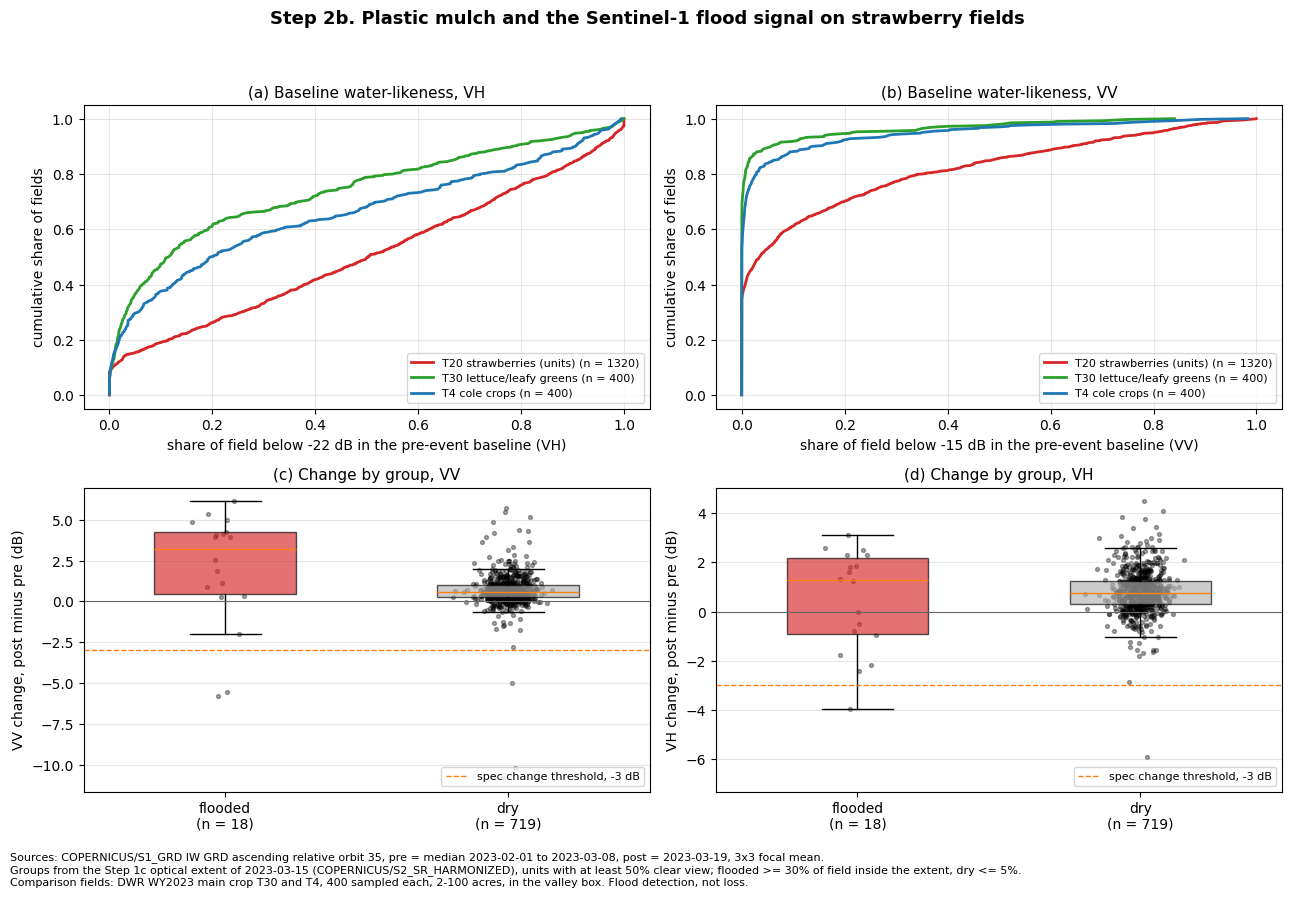

Saved supp_mulch_confound.png
n units = 1320 | date window: S1 post 2023-03-19; optical 2023-03-15 | datasets: COPERNICUS/S1_GRD, COPERNICUS/S2_SR_HARMONIZED, DWR WY2023 crop map


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {"T20": "tab:red", "T30": "tab:green", "T4": "tab:blue"}

for ax, band, thr in [(axes[0, 0], "base_vh", ABS_VH_DB), (axes[0, 1], "base_vv", ABS_VV_DB)]:
    for cls, g in vals.groupby("crop_class"):
        d = np.sort(g[band].dropna().to_numpy())
        ax.plot(d, np.arange(1, len(d) + 1) / len(d), color=colors[cls], lw=2,
                label=f"{LABEL[cls]} (n = {len(d)})")
    pol = band.split("_")[1].upper()
    ax.set_xlabel(f"share of field below {thr:g} dB in the pre-event baseline ({pol})")
    ax.set_ylabel("cumulative share of fields")
    ax.set_title(f"({'a' if band == 'base_vh' else 'b'}) Baseline water-likeness, {pol}", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="lower right")

for ax, col, pol, letter in [(axes[1, 0], "d_vv", "VV", "c"), (axes[1, 1], "d_vh", "VH", "d")]:
    data = [grp_flood[col].dropna().to_numpy(), grp_dry[col].dropna().to_numpy()]
    bp = ax.boxplot(data, tick_labels=[f"flooded\n(n = {len(data[0])})", f"dry\n(n = {len(data[1])})"],
                    showfliers=False, patch_artist=True, widths=0.5)
    for patch, c in zip(bp["boxes"], ["tab:red", "0.7"]):
        patch.set_facecolor(c)
        patch.set_alpha(0.65)
    for i, d in enumerate(data, start=1):
        ax.scatter(np.random.default_rng(0).normal(i, 0.05, len(d)), d, s=8, color="black", alpha=0.35)
    ax.axhline(-3, color="tab:orange", ls="--", lw=1, label="spec change threshold, -3 dB")
    ax.axhline(0, color="0.4", lw=0.8)
    ax.set_ylabel(f"{pol} change, post minus pre (dB)")
    ax.set_title(f"({letter}) Change by group, {pol}", fontsize=11)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Step 2b. Plastic mulch and the Sentinel-1 flood signal on strawberry fields",
             fontsize=13, fontweight="bold")
fig.text(0.01, 0.005,
         f"Sources: {C.S1} IW GRD {PASS.lower()} relative orbit {REL_ORBIT}, pre = median "
         f"{PRE_WINDOW[0]} to 2023-03-08, post = {POST_DATE}, 3x3 focal mean.\n"
         f"Groups from the Step 1c "
         f"optical extent of {OPT_DATE} ({C.S2}), units with at least {CLEAR_MIN:.0%} clear view; "
         f"flooded >= {FLOODED_MIN:.0%} of field inside the extent, dry <= {DRY_MAX:.0%}.\n"
         f"Comparison fields: DWR WY2023 main crop T30 and T4, {N_COMPARE} sampled each, 2-100 acres, "
         f"in the valley box. Flood detection, not loss.",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
FIG = C.FIGURES / "supp_mulch_confound.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name}")
print(f"n units = {N_UNITS} | date window: S1 post {POST_DATE}; optical {OPT_DATE} | "
      f"datasets: {C.S1}, {C.S2}, DWR WY2023 crop map")